# Scailing function

/var/folders/3n/3c918lz14kd61yk6hgz4s1x40000gn/T/ipykernel_41325/2680621890.py:23: RuntimeWarning: overflow encountered in exp
  return L + (U - L) * (1.0 / (1.0 + np.exp(-(p - m) / s)))


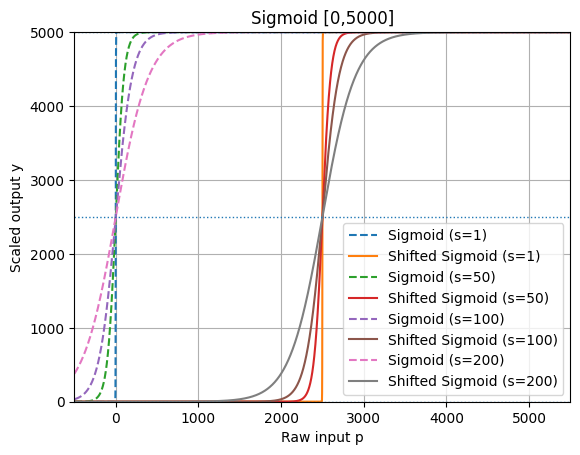

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# User-defined bounds
# =========================
L = 0  # lower bound
U = 5000    # upper bound

m = (L + U) / 2
r = (U - L) / 2

# =========================
# Scaling functions
# =========================
def scaled_sigmoid(p, s):
    return L + (U - L) * (1.0 / (1.0 + np.exp(-p / s)))

def scaled_tanh(p, s):
    return m + r * np.tanh(p / s)

def scaled_sigmoid_shift(p,s):
    return L + (U - L) * (1.0 / (1.0 + np.exp(-(p - m) / s)))

dum_S = min(abs(U), abs(L)) / 4  # dummy sharpness value
# =========================
# Input range + sharpness
# =========================
p = np.linspace(L-500, U+500, 4000)  # or wider, e.g. (-6000, 6000)
s_values = [1,50,100,200]


# =========================
# Overlay plot
# =========================
plt.figure()

for s in s_values:
    plt.plot(p, scaled_sigmoid(p, s),
             linestyle="--",
             label=f"Sigmoid (s={s})")

    # plt.plot(p, scaled_tanh(p, s),
    #          label=f"Tanh (s={s})")
    plt.plot(p, scaled_sigmoid_shift(p, s),
             label=f"Shifted Sigmoid (s={s})")

# Bounds + midpoint
plt.axhline(L, linestyle=":", linewidth=1)
plt.axhline(U, linestyle=":", linewidth=1)
plt.axhline(m, linestyle=":", linewidth=1)

plt.xlabel("Raw input p")
plt.ylabel("Scaled output y")
plt.title(f"Sigmoid [{L},{U}]")
plt.legend()
plt.xlim(p.min(),p.max())
plt.ylim(L,U)
plt.grid(True)
plt.show()
